In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import pylab

In [2]:
# Конечноразностные формулы
def right_der1(u, x, h):
    return (u(x + h) - u(x)) / h

def left_der1(u, x, h):
    return (u(x) - u(x - h)) / h

def avrg_der1(u, x, h):
    return (u(x + h) - u(x - h)) / (2 * h)

def der2(u, x, h):
    return (u(x + h) - 2 * u(x) + u(x - h)) / (h ** 2)

# Функции и их 1-е и 2-е производные
def u1(x):
    return np.sin(x)

def u2(x):
    return np.exp(x)

def u1_der1(x):
    return np.cos(x)

def u1_der2(x):
    return -np.sin(x)

def u2_der1(x):
    return u2(x)

def u2_der2(x):
    return u2(x)

u_der1 = {
    u1: u1_der1,
    u2: u2_der1
}
u_der2 = {
    u1: u1_der2,
    u2: u2_der2
}

# Заголовки
title = {
    u1: r'$\sin \left( x\right)$',
    u2: r'$x^2$'
}
label = {
    right_der1: r"\left | {u}'\left ( x \right )- u_x\left ( x \right ) \right |",
    left_der1: r"\left | {u}'\left ( x \right )- u_{\bar{x}}\left ( x \right ) \right |",
    avrg_der1: r"\left | {u}'\left ( x \right )- u_{\dot{x}}\left ( x \right ) \right |",
    der2: r"\left | {u}''\left ( x \right )- u_{x\bar{x}}\left ( x \right ) \right |"
}

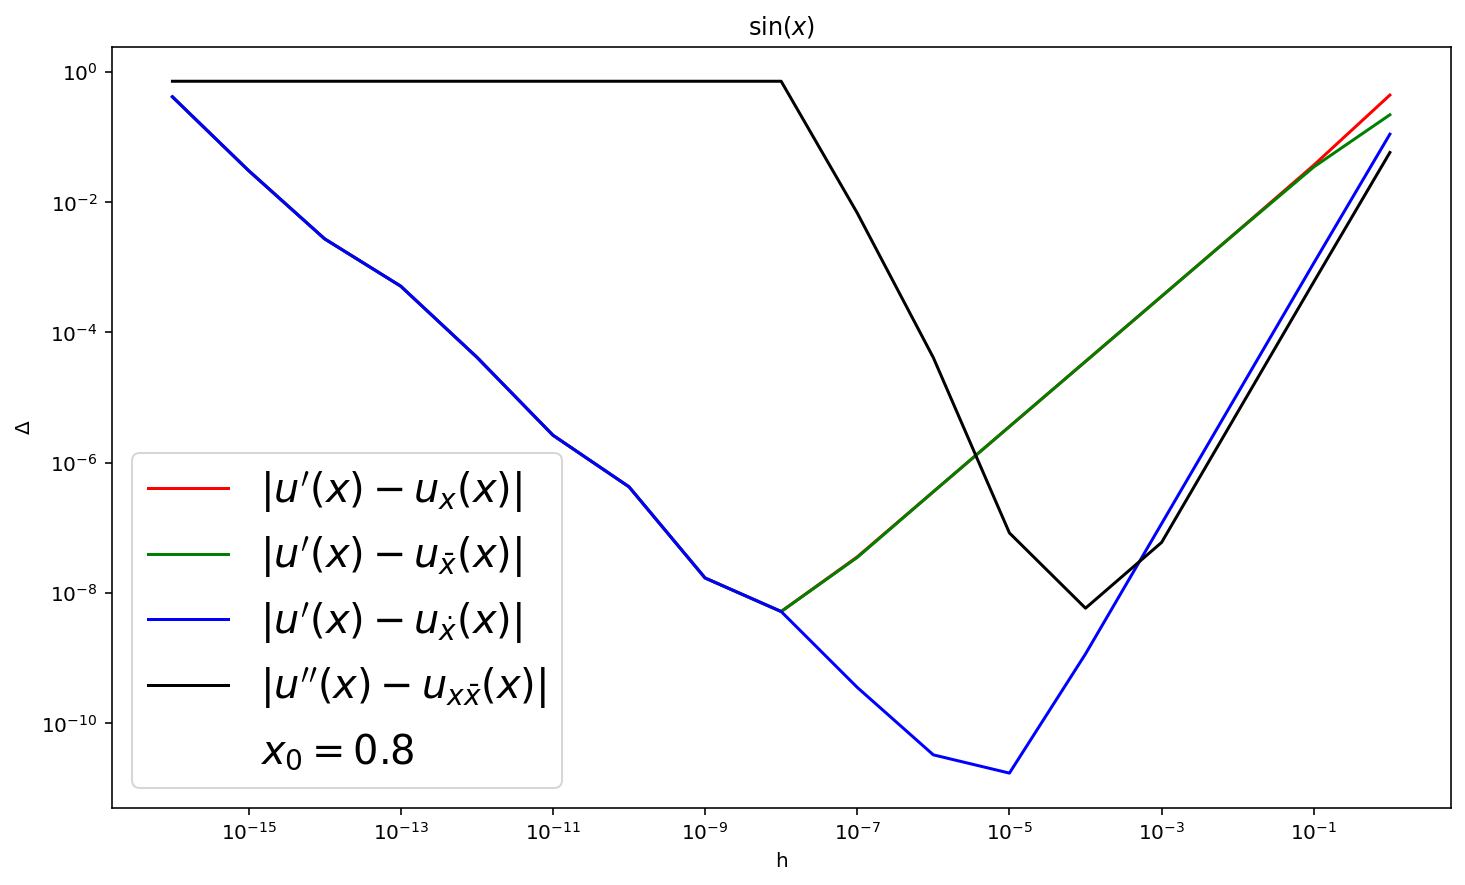

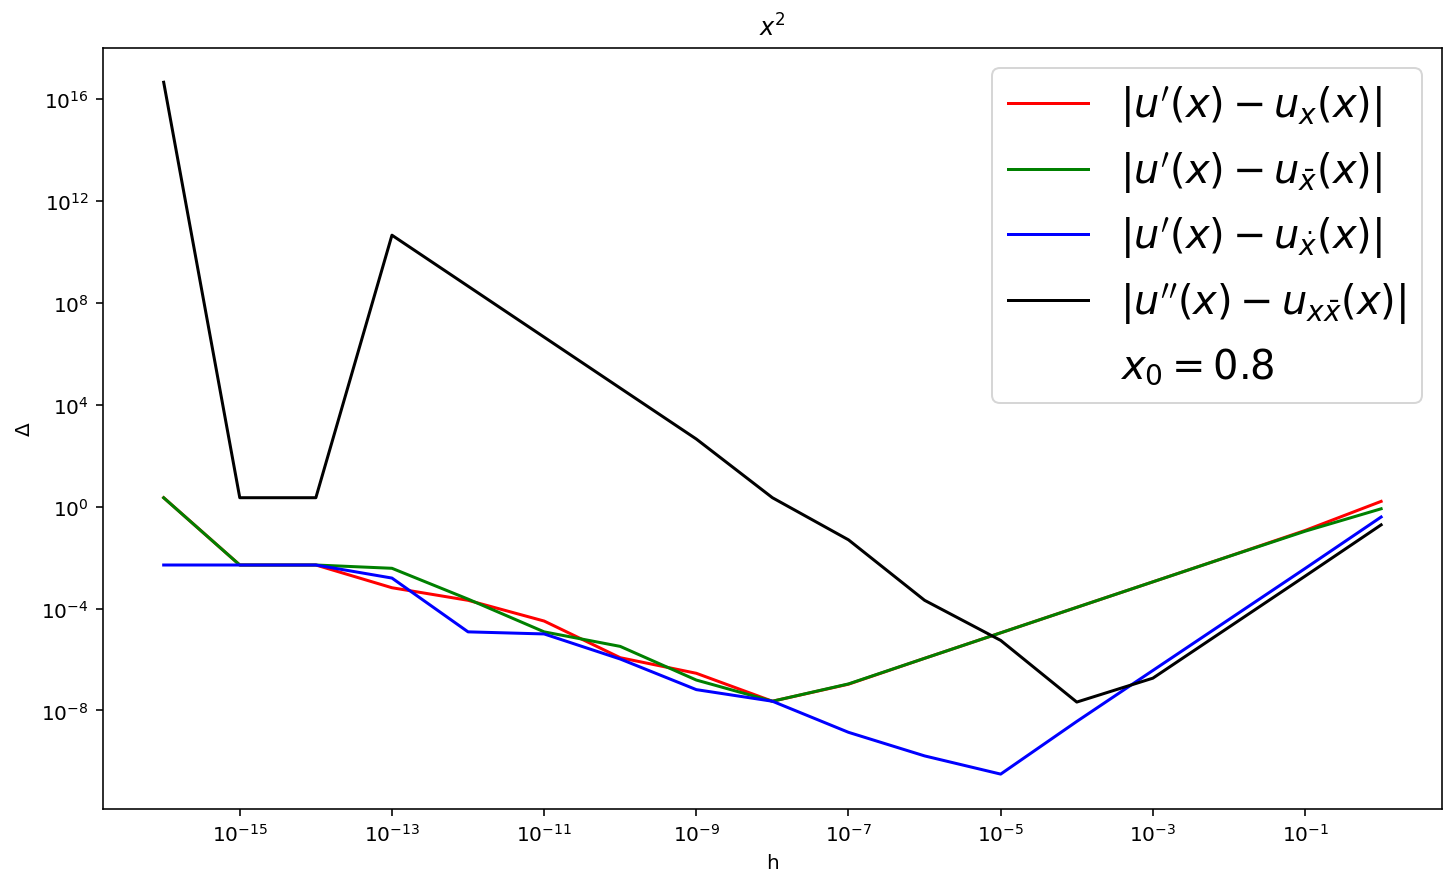

In [3]:
x0 = 0.8
h = np.array([
        10 ** (-k) for k in range(16, -1, -1)
    ])

figure = pylab.figure()

# Построение графиков функций ошибок
for u in [u1, u2]:
    y1 = np.absolute(u_der1[u](x0) - right_der1(u, x0, h))
    y2 = np.absolute(u_der1[u](x0) - left_der1(u, x0, h))
    y3 = np.absolute(u_der1[u](x0) - avrg_der1(u, x0, h))
    y4 = np.absolute(u_der2[u](x0) - der2(u, x0, h))
    
    pylab.plot(h, y1, color='r', label='$%s$' % label[right_der1])
    pylab.plot(h, y2, color='g', label='$%s$' % label[left_der1])
    pylab.plot(h, y3, color='b', label='$%s$' % label[avrg_der1])
    pylab.plot(h, y4, color='k', label='$%s$' % label[der2])
    pylab.plot([], [], ' ', label='$%s$' % r'x_0=0.8')
    pylab.legend(prop={'size': 20})
    pylab.xscale('log')
    pylab.yscale('log')
    pylab.title(title[u])
    pylab.xlabel('h')
    pylab.ylabel('Δ')
    pylab.show()